# Machine Unlearning on MNIST

The goal is to deploy a toy unlearning method over MNIST, for education purposes.

# First, train an MNIST classifier

### Imports

In [37]:
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils.prune as prune

import numpy as np
import matplotlib.pyplot as plt
import copy

import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid

%matplotlib inline

# Data

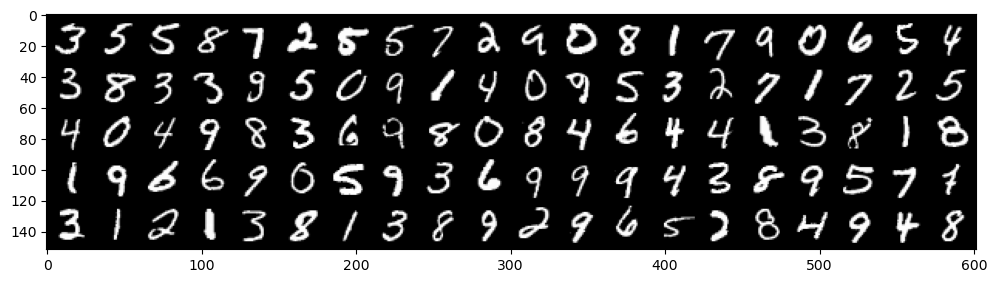

In [38]:
mnist_train = MNIST(root='data/', download=True, train=True, transform=transforms.ToTensor())
train_loader = DataLoader(mnist_train, batch_size=100, shuffle=True)

mnist_test = MNIST(root='data/', train=False, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=500)

def get_dataloaders(train_batch_size = 100, val_split=0.2):
    """Create train and validation dataloaders."""

    val_size = int(len(mnist_train) * val_split)
    train_size = len(mnist_train) - val_size

    train_dataset, val_dataset = random_split(
        mnist_train,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size = train_batch_size, shuffle = True, num_workers = 0)
    val_loader = DataLoader(val_dataset, batch_size = 500, shuffle = False, num_workers = 0)

    print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images\n")

    return train_loader, val_loader

def get_random_batch():
    
    data_iterator = iter(train_loader)
    X, y = next(data_iterator)
    
    return X, y

def check_test_accuracy(model, device, data_loader):
    
    model.eval()
    num_correct = 0
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        with torch.no_grad(): # Gradients aren't needed just for test evaluation
            y_hat = model(X).argmax(-1)
        num_correct += (y_hat == y).cpu().numpy().sum()
    return num_correct / len(mnist_test)

plt.figure(figsize=(12,4));
X, y = get_random_batch()
plt.imshow(make_grid(X, nrow=20).permute((1,2,0)));

In [39]:
X, y = next(iter(train_loader))
X.shape

torch.Size([100, 1, 28, 28])

# Model

In [40]:
class ConvNet(nn.Module):
    def __init__(self):
        """
        """
        super().__init__()
        self.conv1 = nn.Sequential(

            # 28x28 -> 14x14
            nn.Conv2d(1, 8, 3, 2, 1),
            nn.ReLU(),

            # 14x14 -> 7x7
            nn.Conv2d(8, 16, 3, 2, 1),
            nn.ReLU(),

            # 7x7 -> 4x4
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            
            # 4x4 -> 2x2
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        self.flatten = nn.Flatten() # (256,)

        # This will be the first hidden layer
        self.head = nn.Sequential(
            nn.Linear(256, 64), 
            nn.ReLU(),
            nn.Linear(64, 10)
            )
        
    def forward(self, X):
        """
        The actual forward computation is defined here. This is run whenever you "call" the
        `nn.Module`, after it is instantiated.
        
        Here we will write down the computation required to run the model forward, calling
        our previously defined subnetworks
        
        """
        
        B, C, H, W = X.shape

        x = self.conv1(X) # (B x 16 x 1)
        x = self.flatten(x)
        y = self.head(x)
        return y

# Small ViT

In [41]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, max_seq_len=64):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_seq_len, embed_dim))

        # 3 Layers of Attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


        self.head = nn.Sequential(

            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        # x shape: (B, seq_len)
        x = self.embedding(x) + self.pos_embedding
        x = self.transformer(x)

        # global average pool (mean across sequence length)
        x = x.mean(dim=1)

        return self.head(x)


class ViT(nn.Module):
    def __init__(self, embed_dim = None, patch_size = 4, num_channels=1, num_heads=1, num_layers=2, max_seq_len=49, TF_FC_mult = 3):
        """
        """
        super().__init__()
        
        if embed_dim is None:
            embed_dim = patch_size**2 * num_channels

        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size = patch_size, stride = patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, max_seq_len + 1, embed_dim)) # need one extra, for cls token
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * TF_FC_mult,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


        self.head = nn.Sequential(

            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )
        
    def forward(self, x):
        """
        The actual forward computation is defined here. This is run whenever you "call" the
        `nn.Module`, after it is instantiated.
        
        Here we will write down the computation required to run the model forward, calling
        our previously defined subnetworks
        
        """
        
        B = x.shape[0]
    
    # Patchify and flatten: (B, 49, E)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  
        x = x + self.pos_embed
        x = self.transformer(x)
        
        cls_token_final = x[:, 0]

        y = self.head(cls_token_final)
        return y

# Training

In [42]:
def training_regimen(model, opt, scheduler, device, num_epochs = 5):

    # load data
    train_loader, val_loader = get_dataloaders(train_batch_size = 100, val_split = 0.2)
    
    # For each epoch ...
    for k in range(num_epochs):

        # ... grab the current learning rate, 
        current_lr = opt.param_groups[0]["lr"]

        # ... train one epoch
        for i, (X, y) in enumerate(train_loader):
            
            X, y = X.to(device), y.to(device)
            
            opt.zero_grad() # zero gradients
            y_hat = model(X) # forward pass
            likelihood = dist.Categorical(logits=y_hat)
            loss = -likelihood.log_prob(y).mean()
            loss.backward()
            opt.step()

            if i % 50 == 0:
                print(f"Batch {i}: Loss = {loss.cpu().item():.4f}")
 
        # ... eval on validation set
        train_acc = check_test_accuracy(model, device, train_loader)
        val_acc = check_test_accuracy(model, device, val_loader)
        print(f"Epoch {k}: train accuracy = {train_acc:.4f}, val accuracy = {val_acc:.4f}")

        # ... step scheduler
        scheduler.step(val_acc)

        # ... and message if learning rate changed for the next epoch
        new_lr = opt.param_groups[0]['lr']
        if new_lr < current_lr:
            print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        if new_lr < 1e-6:
            print(f"\n[EARLY STOPPING] LR {new_lr:.1e} is below threshold. Training halted.")
            break
        
    return model, opt, scheduler


# Train and Predict on Test

In [43]:
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
classifier = ViT(num_heads=4, embed_dim=24, TF_FC_mult=4).to(device)
# classifier = ConvNet().to(device)
num_params = sum([a.numel() for a in classifier.parameters()])
print(f"ViT: number of parameters = {num_params:,}")
opt = optim.Adam(classifier.parameters(), lr=1e-2)
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.2, patience=1, threshold = .01, threshold_mode = "rel")
model, opt, scheduler = training_regimen(classifier, opt, scheduler, device, num_epochs=10)

ViT: number of parameters = 17,210
Train: 48000 images, Val: 12000 images

Batch 0: Loss = 2.3591
Batch 50: Loss = 1.9466
Batch 100: Loss = 1.9525
Batch 150: Loss = 1.6965
Batch 200: Loss = 1.6132
Batch 250: Loss = 1.3634
Batch 300: Loss = 1.1323
Batch 350: Loss = 1.2106
Batch 400: Loss = 0.9656
Batch 450: Loss = 0.9515
Epoch 0: train accuracy = 3.7944, val accuracy = 0.9448
Batch 0: Loss = 0.5287
Batch 50: Loss = 0.5353
Batch 100: Loss = 0.4924
Batch 150: Loss = 0.6503
Batch 200: Loss = 0.4252
Batch 250: Loss = 0.5835
Batch 300: Loss = 0.4901
Batch 350: Loss = 0.3653
Batch 400: Loss = 0.4206
Batch 450: Loss = 0.2736
Epoch 1: train accuracy = 4.2058, val accuracy = 1.0457
Batch 0: Loss = 0.3778
Batch 50: Loss = 0.3663
Batch 100: Loss = 0.4016
Batch 150: Loss = 0.3387
Batch 200: Loss = 0.2015
Batch 250: Loss = 0.4587
Batch 300: Loss = 0.2760
Batch 350: Loss = 0.3062
Batch 400: Loss = 0.2623
Batch 450: Loss = 0.3247
Epoch 2: train accuracy = 4.3158, val accuracy = 1.0732

[LR REDUCTION] 

In [44]:
check_test_accuracy(classifier, device = "mps")

TypeError: check_test_accuracy() missing 1 required positional argument: 'data_loader'